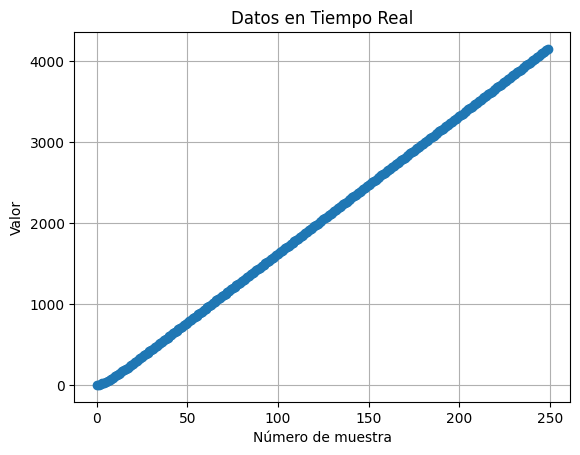

Interrupción del usuario. Cerrando...


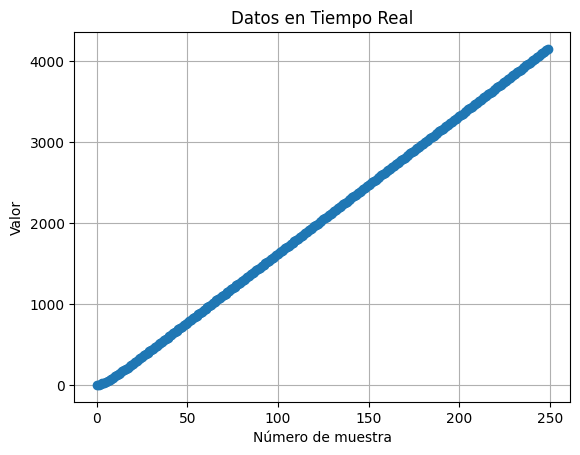

In [9]:
import matplotlib.pyplot as plt
import numpy as np
import serial
import time
from IPython.display import display, clear_output

# Configura el puerto serial (ajusta el nombre del puerto y la velocidad según tu configuración)
ser = serial.Serial('COM16', 9600)  # Usa '/dev/ttyUSB0' en Linux o '/dev/ttyACM0' en algunas placas Arduino
time.sleep(2)  # Espera a que la conexión se establezca

# Configura la gráfica
plt.ion()  # Modo interactivo
fig, ax = plt.subplots()
x_data = []
y_data = []

# Inicializa el contador de muestras
sample_count = 0

try:
    while True:
        # Lee el dato del puerto serial
        if ser.in_waiting > 0:
            try:
                line = ser.readline().decode('utf-8').strip()
                y = float(line)  # Convierte el dato a flotante
                x = sample_count
                x_data.append(x)
                y_data.append(y)
                sample_count += 1
                
                
                # Actualiza la gráfica
                ax.clear()
                ax.plot(x_data, y_data, marker='o')
                ax.set_xlabel('Número de muestra')
                ax.set_ylabel('Valor')
                ax.set_title('Datos en Tiempo Real')
                plt.draw()
                plt.grid()
                
                # Usa IPython.display para mostrar la gráfica en Jupyter Notebook
                clear_output(wait=True)
                display(fig)
                
            except ValueError:
                # Si no se puede convertir a float, ignora el dato
                pass

except KeyboardInterrupt:
    print("Interrupción del usuario. Cerrando...")
finally:
    ser.close()
    plt.ioff()  # Modo no interactivo
    plt.show()


In [ ]:
import pandas as pd
df = pd.DataFrame(x_data2, y_data)

df.to_excel('data.xlsx')

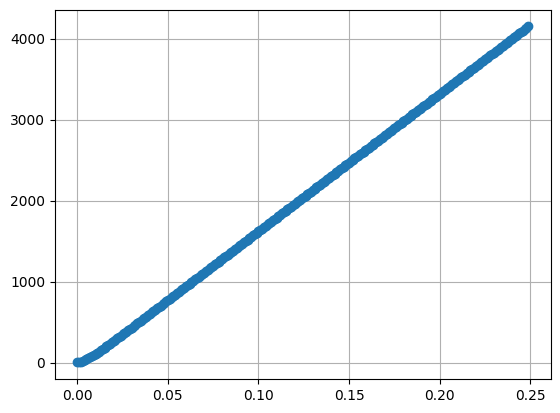

In [13]:
import numpy as np
x_data2 = np.array(list(map(lambda x: x * 0.001, x_data)))
plt.plot(x_data2, y_data, marker='o')
plt.grid()
plt.show()